# Esame Laboratorio di Programmazione II - 28/08/2025


Scrivete chiaramente sul notebook il vostro nome e matricola e sul nome con cui salvate il file la vostra matricola.

Per ogni funzione e metodo che richiede un campionamento rispetto ad una distribuzione settate il seed a 0: ``np.random.seed(0)``.

Stampate il risultato delle domanda e consegnate il compito eseguito, quindi per cui ogni cella ha il corrispondente output.
Quindi ad esempio

e.g., 
NON scrivete: 
```python 
    lista=np.array([1,2,3])
```
ma 
```python
    lista=np.array([1,2,3]) 
    print('lista =', lista)   
```
Attenzione!Se scrivete:
```python
    lista=np.array([1,2,3])
    lista
```
``lista`` sarà l'unico ouput che si vede di quella cella

NB se l'output è una matrice molto grande non dovete stamparla.

Sarà valutata anche la presentazione, ad esempio un plot senza ettichette sugli assi o illleggibili sarà valutato meno bene di uno con ettichette chiare.

Commentate il compito di modo che si capisca cosa avete fatto.

Controllate attentamente di avere consegnato il file giusto.

In [1]:
#Potete importare direttamente qui le librerie che userete
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

## Esercizio 1

Supponiamo che i seguenti valori rappresentino il numero di ore di sonno dormite ogni notte nelle ultime **due settimane**:  
**6.5, 5.0, 7.8, 8.2, 4.9, 6.0, 7.0, 7.5, 6.8, 5.5, 8.0, 6.3, 7.2, 5.8**

1. Inserisci questi valori in un array NumPy

2. Crea un nuovo array che assegna un **punteggio di qualità del sonno** secondo le seguenti regole:
   - `1` se il sonno è **inferiore a 6 ore**
   - `2` se è **tra 6 ore (incluse) e meno di 8 ore**
   - `3` se è **8 ore o più**

3. Calcola la **percentuale di notti** per ciascuna fascia di qualità del sonno:
   - Percentuale di notti con punteggio **1** (meno di 6 ore)
   - Percentuale di notti con punteggio **2** (tra 6 e meno di 8 ore)
   - Percentuale di notti con punteggio **3** (8 ore o più)


In [8]:
#1
ore = np.array([6.5, 5.0, 7.8, 8.2, 4.9, 6.0, 7.0, 7.5, 6.8, 5.5, 8.0, 6.3, 7.2, 5.8], dtype=float)
#2
def assegna_punt(ore):
    new = []
    for x in ore:
        if x<6:
            punteggio=1
        elif (x>=6) and (x<8):
            punteggio=2
        else:
            punteggio=3
        new.append(punteggio)
    new = np.array(new)
    return new
print("Nuovo array con punteggi",assegna_punt(ore))
punteggi = assegna_punt(ore)
#3
n = len(ore)
somm_1 = np.sum(punteggi == 1)
somm_2 = np.sum(punteggi == 2)
somm_3 = np.sum( punteggi == 3)
perc_1 = (somm_1/n)*100
perc_2 = (somm_2/n)*100
perc_3 = (somm_3/n)*100
print(f"\nPercentuale 1: {perc_1}, percentuae 2: {perc_2}, percentuale 3:{perc_3}")

Nuovo array con punteggi [2 1 2 3 1 2 2 2 2 1 3 2 2 1]

Percentuale 1: 28.57142857142857, percentuae 2: 57.14285714285714, percentuale 3:14.285714285714285


## Esercizio 2
Un’urna contiene 3 palline rosse e 2 blu. A ogni estrazione si rimette la pallina nell’urna.
Quindi ad esempio la propabilità di estarre una pallina rossa è 3/5.
1. Scrivi una funzione che simula N estrazioni e rappresentale con un array NumPy (1 = rosso, 0 = blu).  Esempio: estrazioni_palline(3) = array([0,0,1])
2. Calcola la proporzione cumulativa di palline rosse dopo 10, 20, 30, …, 100 estrazioni. Siignifica ad esempio che per N estrazioni, contiamo quante volte è uscita una pallina rossa e dividiamo per 10.
3. Fai un grafico dell’andamento della proporzione cumulativa in funzione del numero di estrazioni.



[1 0 0]


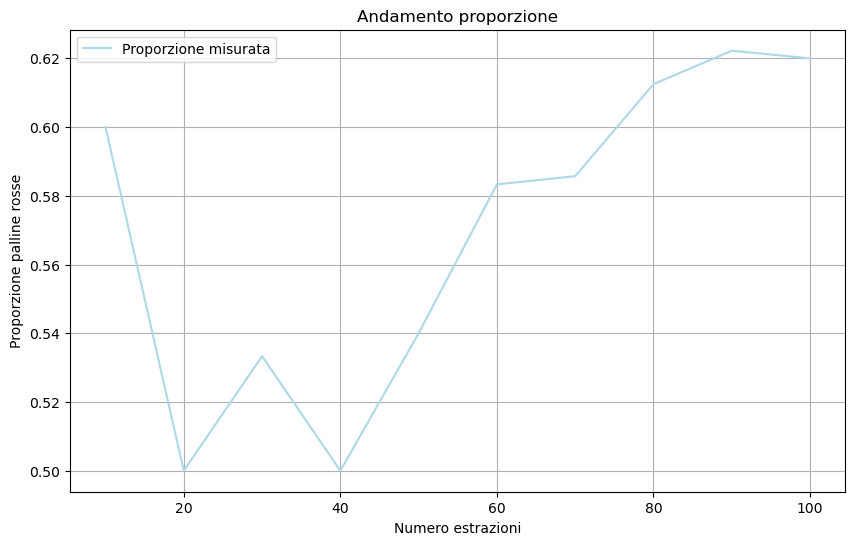

In [16]:
np.random.seed(0)
def estrazione(N):
    risultati = np.random.choice([1,0], size=N, p=(3/5, 2/5))
    return(risultati)
#es 
print(estrazione(3))
#2
N = 100
lanci= estrazione(N)
punti_controllo = np.arange(10,101,10)
proporz = [] 
for n in punti_controllo:
    estraz_parz = lanci[:n]
    num_rosse = np.sum(estraz_parz)
    proporzione = num_rosse/n
    proporz.append(proporzione)
#3
plt.figure(figsize=(10,6))
plt.plot(punti_controllo, proporz, color="lightblue", label="Proporzione misurata")
plt.title("Andamento proporzione")
plt.xlabel("Numero estrazioni")
plt.ylabel("Proporzione palline rosse")
plt.grid(True)
plt.legend()
plt.show()

## Esercizio 3

1. Genera una matrice NumPy di dimensioni 8 x 8, con valori interi casuali compresi tra -20 e 20 (inclusi).

2. Per ogni riga, seleziona il numero **più vicino a 10**.

In [15]:
#1
np.random.seed(0)
matrice = np.random.randint(low=-20, high=20, size=(8,8))
print("Matrice:\n ", matrice)
#2
distanze_da_10 = np.abs(matrice-10)
min= np.argmin(distanze_da_10, axis=1)
piu_vicini = matrice[np.arange(8), min]
print("Valori per riga più vicini a 10: \n", piu_vicini)

Matrice:
  [[-20 -17 -17  19 -11  -1   1  16]
 [  3 -14   4   4  -8 -19  18  19]
 [  3   4  -3  17   5  -7 -12 -11]
 [  0  -4 -15  -5 -20  -2  15   4]
 [  9  -1  -1  -6  19  12 -19 -11]
 [ 12  11 -10   3  15  -9   8  14]
 [-20 -20  16 -15  18  -3  -5 -16]
 [ 11 -19 -19  19  15  18  -9  -2]]
Valori per riga più vicini a 10: 
 [16  4  5 15  9 11 16 11]


## Esercizio 4  

Utilizza il dataset `movies.csv` (contenente colonne come `title`, `budget`, `revenue`, `vote_average`, `vote_count`).  

1. Elimina le righe con i valori mancanti. e **Crea una nuova colonna** `roi` (return on investment), definita come:  

   $$
   \texttt{roi} = \frac{\texttt{revenue} - \texttt{budget}}{\texttt{budget}}
   $$  

   *(Indica di quanto il film ha guadagnato rispetto al costo di produzione).*  

2. Trova i **5 film con ROI più alto** e stampa `title` e `roi`.  

3. **Filtra i film** che hanno:  
   - `budget` > 50 milioni  
   - `vote_average` > 7  

4. **Crea un grafico a barre** con i **10 film con ROI più alto**.  

5. **Crea uno scatter plot** con:  
   - asse x = `budget`  
   - asse y = `revenue`  
   - colore dei punti = `vote_average`  


       id    imdb_id  popularity  ...  release_year   budget_adj   revenue_adj
0  135397  tt0369610   32.985763  ...          2015  137999939.3  1.392446e+09
1   76341  tt1392190   28.419936  ...          2015  137999939.3  3.481613e+08
2  262500  tt2908446   13.112507  ...          2015  101199955.5  2.716190e+08
3  140607  tt2488496   11.173104  ...          2015  183999919.0  1.902723e+09

[4 rows x 21 columns]
Primi 5 film con roi più alto: 
                original_title           roi
3608       From Prada to Nada  26880.720430
7447      Paranormal Activity  12889.386667
2449  The Blair Witch Project   9919.000000
3581  Love, Wedding, Marriage   1377.000000
242               The Gallows    425.644100


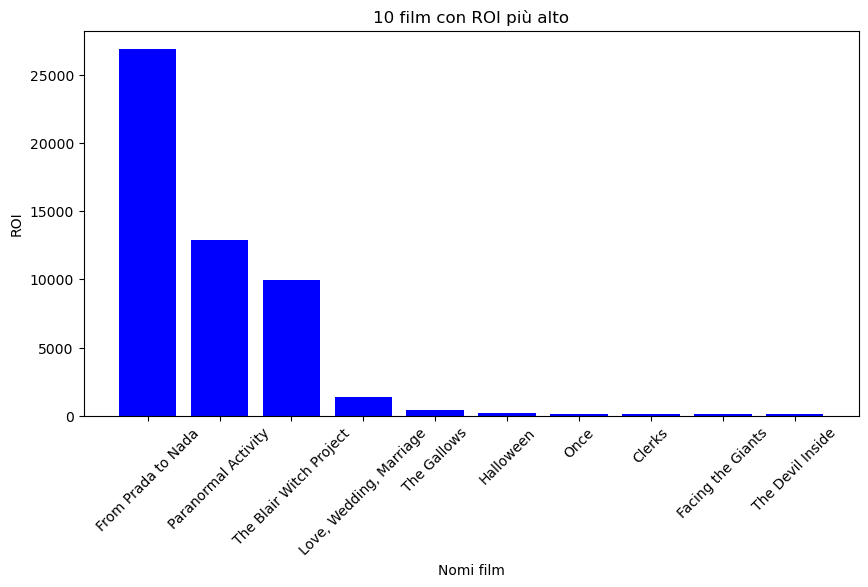

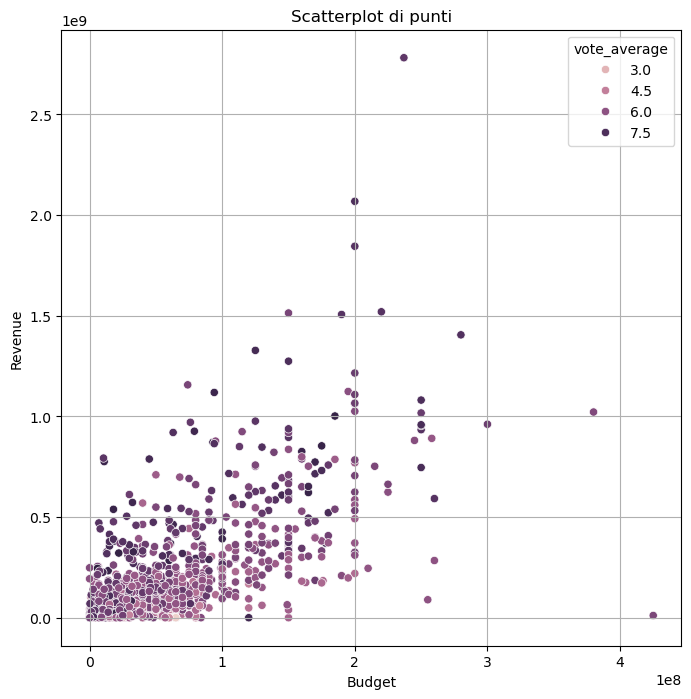

In [ ]:
df = pd.read_csv("movies.csv")
print(df.head(4))
#1
df = df.dropna()
df = df[df["budget"]>0]
df["roi"]=(df["revenue"]-df["budget"])/df["budget"]
#2
df_ordinato = df.sort_values(by="roi", ascending=False)
print("Primi 5 film con roi più alto: \n", df_ordinato[["original_title", "roi"]].head(5))
#3
vero_falso = (df["budget"]>50000000) & (df["vote_average"] >7)
df_filtrato = df[vero_falso]
#4
plt.figure(figsize=(10,5))
plt.bar(df_ordinato["original_title"].head(10), df_ordinato["roi"].head(10), color="blue")
plt.title("10 film con ROI più alto")
plt.xlabel("Nomi film")
plt.ylabel("ROI")
plt.xticks(rotation=45)
plt.show()
#5
plt.figure(figsize=(8,8))
sns.scatterplot(data=df, x="budget", y="revenue", hue="vote_average")
plt.title("Scatterplot di punti")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

## Esercizio 5  

Utilizza il dataset `movies.csv`.  

1. Quante **righe e colonne** ha il dataset? Successivamente elimina la colonna `overview` dal DataFrame.  
2. Trova il **regista** (`director`) che ha diretto il maggior numero di film.  
3. Calcola il **vote_average medio** per ciascun `director` e ordina i primi 10.  
4. Crea un **boxplot** dei valori di `vote_average` raggruppati per `director` (solo i 5 registi con più film).  
5. Crea un **violin plot** della distribuzione dei `vote_average` per genere (`genres`).  


Numero righe e colonne del dataset:  (10866, 21)

Il regista Woody Allen ha diretto il maggior numero di film.

Voto_average medio per ciascun regista:
 director
Mark Cousins                                   9.2
Derek Frankowski                               8.8
David Mallet                                   8.7
Martin Scorsese|Michael Henry Wilson           8.5
Saul Swimmer                                   8.5
James Payne                                    8.5
Curt Morgan                                    8.5
D.A. Pennebaker|David Dawkins|Chris Hegedus    8.4
Anthony Mandler                                8.4
Jorge RamÃ­rez SuÃ¡rez                         8.4
Name: vote_average, dtype: float64


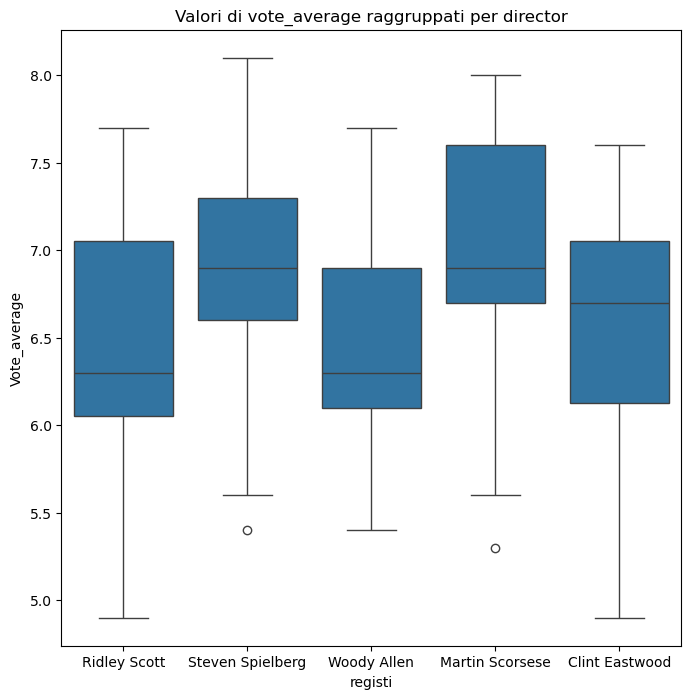

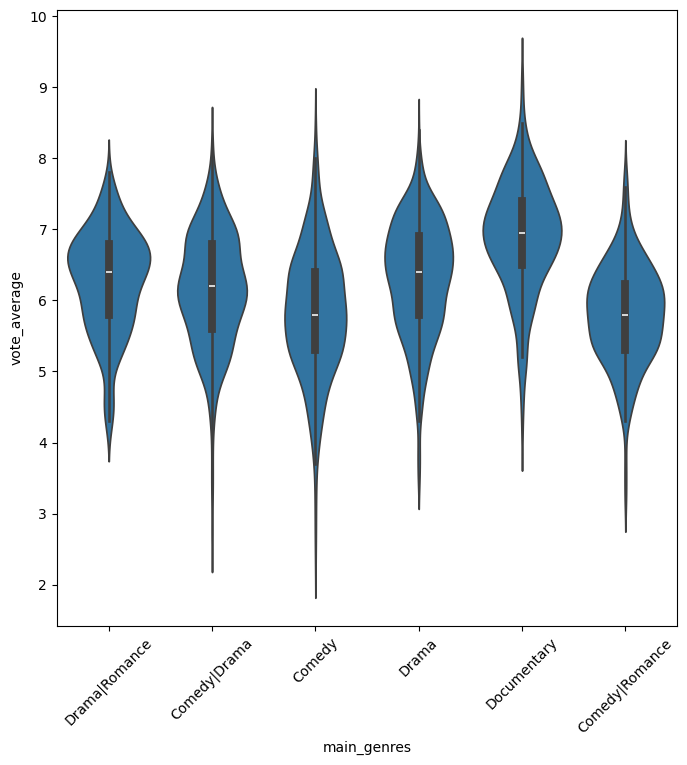

In [47]:
df = pd.read_csv("movies.csv")
#1
dimensioni = df.shape
print("Numero righe e colonne del dataset: ", dimensioni)
df = df.drop(columns="overview")
#2
regista_popolare = df["director"].mode()[0]
print(f"\nIl regista {regista_popolare} ha diretto il maggior numero di film.")
#3
vote_average_medio = df.groupby("director")["vote_average"].mean()
voto_ordinato = vote_average_medio.sort_values(ascending=False)
print("\nVoto_average medio per ciascun regista:\n",voto_ordinato.head(10))
#4
conteggio = df.groupby("director")["original_title"].count().sort_values(ascending=False).head(5)
indici_top_5 = conteggio.index
df_filtrato_top5 = df[df["director"].isin(indici_top_5)]
plt.figure(figsize=(8,8))
sns.boxplot(data = df_filtrato_top5, x="director", y="vote_average")
plt.title("Valori di vote_average raggruppati per director")
plt.xlabel("registi")
plt.ylabel("Vote_average")
plt.show()
#5
df["main_genres"] = df["genres"].str.split(",").str[0]
top_generi = df["main_genres"].value_counts().head(6).index
generi_filtrati = df[df["main_genres"].isin(top_generi)]
plt.figure(figsize=(8,8))
sns.violinplot(data = generi_filtrati, x="main_genres", y="vote_average")
plt.xticks(rotation=45)
plt.show()


## Esercizio 6  

Hai a disposizione il dataset di coppie `(x, y)`  qui sotto riportato.

1. Usa `scipy.optimize.curve_fit` per stimare i parametri della retta del tipo `y = a * x + b`.  
2. Plotta i punti originali e la retta ottenuta.  
3. Calcola **MAE** e **RMSE** tra i valori reali `y` e quelli stimati dal modello.  


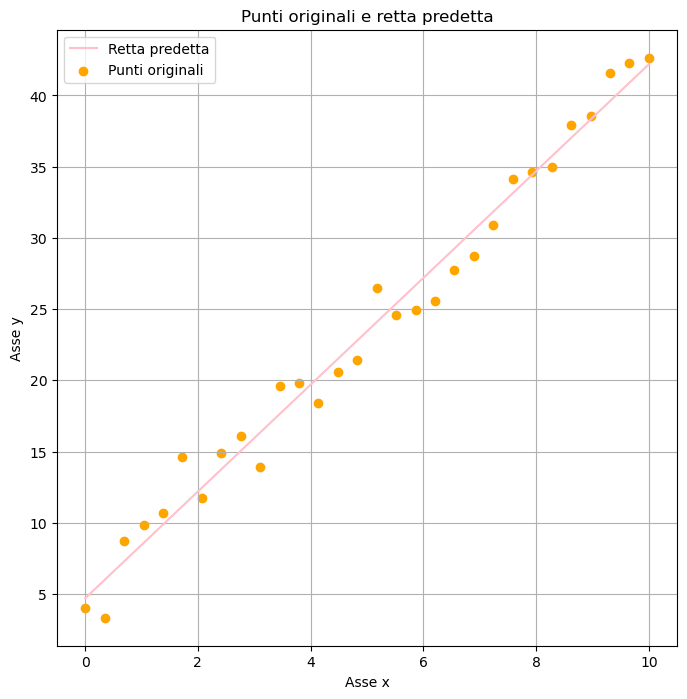

MAE: 1.3702968267678388, RMSE: 1.5627464698505418


In [49]:
x = np.array([
  0.0, 0.3448, 0.6897, 1.0345, 1.3793, 1.7241,
  2.0690, 2.4138, 2.7586, 3.1034, 3.4483, 3.7931,
  4.1379, 4.4828, 4.8276, 5.1724, 5.5172, 5.8621,
  6.2069, 6.5517, 6.8966, 7.2414, 7.5862, 7.9310,
  8.2759, 8.6207, 8.9655, 9.3103, 9.6552, 10.0
])

y = np.array([
   3.99,  3.33,  8.71,  9.83, 10.69, 14.59,
  11.72, 14.87, 16.06, 13.93, 19.61, 19.83,
  18.40, 20.59, 21.45, 26.51, 24.57, 24.94,
  25.55, 27.78, 28.71, 30.87, 34.14, 34.65,
  35.01, 37.94, 38.53, 41.56, 42.28, 42.65
])
#1
def modello_retta(x, a, b):
    return (a*x)+b
parametri, cov = curve_fit(modello_retta,x , y)
a_pred , b_pred = parametri
y_pred = modello_retta(x, a_pred, b_pred)
#2
plt.figure(figsize=(8,8))
plt.plot(x,y_pred,color="pink", label="Retta predetta")
plt.scatter(x, y,color="orange", label="Punti originali")
plt.grid(True)
plt.legend()
plt.title("Punti originali e retta predetta")
plt.xlabel("Asse x")
plt.ylabel("Asse y")
plt.show()
#3
mae = mean_absolute_error(y, y_pred)
rmse = root_mean_squared_error(y, y_pred)
print(f"MAE: {mae}, RMSE: {rmse}")
